In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import numpy as np

from flonacomldft.utils.io_utils import save_pickle_file, load_pickle_file, load_csv_file, get_project_path
from flonacomldft.internal_coordinates import Coordinates_mapping, get_collective_variables_from_xs

In [2]:
# 300 K results #OLD RESULTS
# path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
# simulations = ["results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl",
#               "results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl"]

# 350 K results #OLD RESULTS
# path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
# adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
#                     '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']
# 
# adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
#                      '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
#                     '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

# NEW RESULTS 350 K
path = get_project_path()

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_29941693/adaptive_sampling_is0_29941693.pkl',
                    '1-adaptive/results_adaptive_is1_29941697/adaptive_sampling_is1_29941697.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_30019623/adaptive_sampling_is0_30019623.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_30019627/adaptive_sampling_is1_30019627.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [12]:
np_predictor = {}

for i in range(2):
    model = adaptives_mlp[i]['dict_mlps'][-1][0]['model']
    datasets = adaptives_mlp[i]['mlps_datasets'][0]
    us_predict = {key: model(datasets[key][0][:, :12]) for key in datasets.keys()}
    np_predictor[i] = {'prediction': us_predict,
                          'datasets': {key: datasets[key][0][:, 12] for key in datasets.keys()} } 

In [3]:
import matplotlib.pyplot as plt

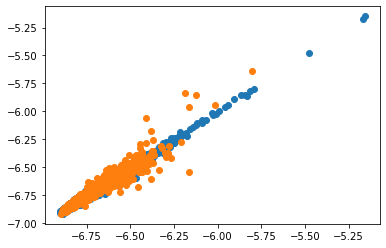

In [14]:
for key in datasets.keys():
    plt.plot(np_predictor[0]['datasets'][key].detach().numpy(),
                np_predictor[0]['prediction'][key].detach().numpy(), 'o', label=key)

In [12]:
def get_info_from_adaptive(adaptive):
    
    accs = torch.cat(adaptive['accs']).float().mean(dim=1)
    us = torch.cat(adaptive['us'])
    xs = torch.cat(adaptive['xs'])
    isomers = torch.cat(adaptive['isomers'])

    cvs = get_collective_variables_from_xs(xs, isomers)

    #part_ratios = compute_part_ratios_per_adaptive(adaptive, path, isomer)

    flow_models = adaptive["dict_flows"]

    nlls = []
    for i in range(30):
        nll = []
        for x in adaptive['xs'][i]:
            nll.append(flow_models[i][0]['model'].nll(x))
        nll = torch.stack(nll)
        nlls.append(nll)

    to_return = {
        'accs' : accs,
        'us' : us,
        'nlls' : nlls,
        'cvs' : cvs,
    }

    return to_return

In [13]:
keys = ['ab-flowMC w.o NP', 'ab-flowMC', 'MD']
color_keys = dict(zip(keys, ['blue', 'orange', 'green']))

In [14]:
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys[:-1], [adaptive_dft_path[0], adaptive_mlp_path[0]])}
adaptives_is1 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys[:-1], [adaptive_dft_path[1], adaptive_mlp_path[1]])}

In [15]:
adaptive_path_is0 = {keys[0]: adaptive_dft_path[0],
                     keys[1]: adaptive_mlp_path[0]}

adaptive_path_is1 = {keys[0]: adaptive_dft_path[1],
                     keys[1]: adaptive_mlp_path[1]}

In [16]:
adaptive_info_is0 = {key: get_info_from_adaptive(adaptives_is0[key]) for key in keys[:-1]}
adaptive_info_is1 = {key: get_info_from_adaptive(adaptives_is1[key]) for key in keys[:-1]}

In [13]:
save_plot_data = "data_for_plots"

In [23]:
save_pickle_file(adaptive_info_is0, 'ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
save_pickle_file(adaptive_info_is1, 'ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

In [16]:
save_pickle_file(np_predictor, 'np_predictions_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)

In [18]:
flow_samples = {}

for i in range(2):
    N = 2500
    model = adaptives_mlp[i]['dict_flows'][15][0]['model']
    samples = model.sample(N)
    nll = model.nll(samples).reshape(-1, 1)
    cvs = get_collective_variables_from_xs(samples.reshape(N, 1, 12), 
                                           torch.ones((N, 1, 1))*i)
    flow_samples[i] = torch.cat((cvs.squeeze(), nll), dim=1).detach().numpy()

In [14]:
save_pickle_file(flow_samples, 'flow_samples_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)

In [6]:
import pandas as pd
import seaborn as sns

In [19]:
df = pd.DataFrame(flow_samples[1].squeeze(), columns=['CV1', 'CV2', 'NLL'])

<AxesSubplot:xlabel='CV1', ylabel='CV2'>

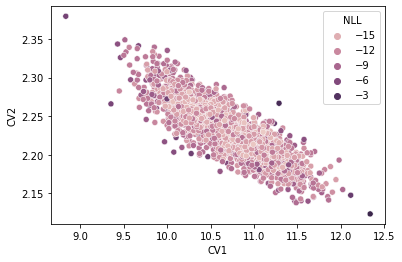

In [21]:
sns.scatterplot(
    data=df, x="CV1", y="CV2", hue="NLL",
    #fill=False, common_norm=True, color="black",
    #levels=5, linestyle=':', linewidths=1,
)
